In [1]:
import pandas as pd
from pathlib import Path

jurkat_path = Path('../data/jurkat_specific_ranked.csv')
expanded_DB_path = Path('../data/expandedDB.csv')

jurkat = pd.read_csv(jurkat_path)
expanded_DB = pd.read_csv(expanded_DB_path)


In [2]:
jurkat['protein_id'] = jurkat['string_external_id'].str.split('.').str[1]
expanded_DB['protein_id'] = expanded_DB['protein_id'].str.split('.').str[0]

# Keep only columns that should come from expanded_DB so the two merges stay aligned
payload_columns = [
    col for col in expanded_DB.columns
    if col not in {'gene_name', 'protein_id'} and col not in jurkat.columns
]

expanded_by_gene = expanded_DB[['gene_name'] + payload_columns].copy()
expanded_by_protein = expanded_DB[['protein_id'] + payload_columns].copy()

jurkat = jurkat.reset_index(names='row_id')
gene_merge = jurkat.merge(expanded_by_gene, on='gene_name', how='left').set_index('row_id')
protein_merge = jurkat.merge(expanded_by_protein, on='protein_id', how='left').set_index('row_id')

jurkat = gene_merge.combine_first(protein_merge).reset_index(drop=True)
jurkat.drop(columns=['string_external_id'], inplace=True)
jurkat = jurkat.drop(columns=[
    col for col in jurkat.columns
    if 'predictedte' in col.lower().replace('_', '').replace(' ', '') or 'cds' in col.lower().replace('_', '').replace(' ', '')
], errors='ignore')

jurkat 

,rank,gene_name,jurkat_abundance_ppm,jurkat_raw_spectral_count,protein_id,gene_id,transcript_id,5' UTR,start_codon,stop_codon,...,5_UTR,3_UTR,5_UTR_len,3_UTR_len,IRES count,IRES IDs,5_len,3_len,5_UTR_MFE,3_UTR_MFE
0,1,ARHGDIB,1703.000,1333477153,ENSP00000228945,ENSG00000111348.10,ENST00000228945.9,GCCAGTACTCAGAAGTCAGAGTTGAGAGACAGAGGCACCCCGGACA...,ATG,TGA,...,GCCAGTACTCAGAAGTCAGAGTTGAGAGACAGAGGCACCCCGGACA...,TGAATGCATCCACCCCTTTCCCCACCCTTGCCACCTGGAAGAATTC...,77.0,494.0,0.0,NaN,77.0,494.0,-9.5,-97.9
1,2,SH2D1A,586.000,166821018,ENSP00000360181,ENSG00000183918.18,ENST00000371139.9,GACTTGTGCCTGGCTGCAGTAGCAGCGGCATCTCCCTTGCACAGTT...,ATG,TGA,...,GACTTGTGCCTGGCTGCAGTAGCAGCGGCATCTCCCTTGCACAGTT...,NaN,80.0,0.0,0.0,NaN,80.0,0.0,-23.2,NaN
2,3,IFI16,511.000,983371519,ENSP00000357113,ENSG00000163565.21,ENST00000295809.12,ATTTTCTCTGGGGCAATAGCAGAATAGGAGCAAGCCAGCACTAGTC...,ATG,TAA,...,ATTTTCTCTGGGGCAATAGCAGAATAGGAGCAAGCCAGCACTAGTC...,NaN,275.0,0.0,0.0,NaN,275.0,0.0,-57.1,NaN
3,4,GLIPR2,296.000,100501029,ENSP00000367196,ENSG00000122694.17,ENST00000377960.9,GCAGTGCAGCGCAGCCGCGGGGAGCGAGGAGCGCGCGGAGCCGGCC,ATG,TAA,...,GCAGTGCAGCGCAGCCGCGGGGAGCGAGGAGCGCGCGGAGCCGGCC,NaN,46.0,0.0,0.0,NaN,46.0,0.0,-18.0,NaN
4,5,CARHSP1,284.000,95742993,ENSP00000379838,ENSG00000153048.12,ENST00000311052.10,AGTCGGAGCGAAGCGGCTGGCGGAGCAGAACGGATTGCAGGGTCAGCC,ATG,TAG,...,AGTCGGAGCGAAGCGGCTGGCGGAGCAGAACGGATTGCAGGGTCAGCC,TAGGAGATGGTGGAAGCACCCCTTGTCCTGTGCTTGTGGGAGACTT...,48.0,2220.0,0.0,NaN,48.0,2220.0,-14.7,-832.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,507,RAD17,0.022,67686,ENSP00000426191,ENSG00000152942.20,ENST00000354868.10,GTACCTCCGAGAGGCTCGGCGTTGAGCCCGGGTAGGGCCAGGTGGC...,ATG,TAG,...,GTACCTCCGAGAGGCTCGGCGTTGAGCCCGGGTAGGGCCAGGTGGC...,NaN,532.0,0.0,0.0,NaN,532.0,0.0,-129.3,NaN
508,508,FAM71C,0.016,85301,ENSP00000315247,ENSG00000180219.2,ENST00000324341.2,AGCAGTGGATGGTTCAGGTTGGGAAGAAGAGCAGTGGGATTGCCAG...,ATG,TGA,...,AGCAGTGGATGGTTCAGGTTGGGAAGAAGAGCAGTGGGATTGCCAG...,NaN,422.0,0.0,0.0,NaN,422.0,0.0,-136.8,NaN
509,509,CIC,0.016,48490,ENSP00000458663,ENSG00000079432.10,ENST00000681038.1,ACCATTTTGTGTGTTGGAGTAAAAAAAAAAGGGAGAATCGAGAGGG...,ATG,TGA,...,ACCATTTTGTGTGTTGGAGTAAAAAAAAAAGGGAGAATCGAGAGGG...,NaN,140.0,0.0,0.0,NaN,140.0,0.0,-53.3,NaN
510,510,IPO13,0.004,85301,ENSP00000361418,ENSG00000117408.12,ENST00000372343.8,GCTTGTCTTGTCAGTCACTGGGGCGGAGGCAGCGGCTGTAGCGGGG...,ATG,TGA,...,GCTTGTCTTGTCAGTCACTGGGGCGGAGGCAGCGGCTGTAGCGGGG...,NaN,651.0,0.0,0.0,NaN,651.0,0.0,-292.9,NaN


In [23]:
jurkat.columns

Index(['rank', 'gene_name', 'jurkat_abundance_ppm',
       'jurkat_raw_spectral_count', 'protein_id', 'gene_id', 'transcript_id',
       '5' UTR', 'start_codon', 'stop_codon', '3' UTR', 'appris_rank',
       '5' UTR_len', '3' UTR_len', 'protein_sequence', 'matches_gencode_aa',
       '5_UTR_GC', '3_UTR_GC', 'global_GC', '5_AREs', '3_AREs', 'uAUG_count',
       'uORF_in_frame', 'dORF_with_stop', 'dORF_truncated', '5_UTR', '3_UTR',
       '5_UTR_len', '3_UTR_len', 'IRES count', 'IRES IDs', '5_len', '3_len',
       '5_UTR_MFE', '3_UTR_MFE'],
      dtype='str')

In [3]:
no_match = jurkat[jurkat['gene_id'].isnull()]

print(len(no_match))

17


In [4]:
# Drop rows from expanded_DB that match jurkat by gene_name or protein_id
jurkat_gene_names = set(jurkat['gene_name'].dropna()) if 'gene_name' in jurkat.columns else set()
jurkat_protein_ids = set(jurkat['protein_id'].dropna().astype(str)) if 'protein_id' in jurkat.columns else set()

expanded_for_match = expanded_DB.copy()
expanded_for_match['protein_id'] = expanded_for_match['protein_id'].astype(str).str.split('.').str[0]

mask = pd.Series(False, index=expanded_for_match.index)
if 'gene_name' in expanded_for_match.columns and jurkat_gene_names:
    mask |= expanded_for_match['gene_name'].isin(jurkat_gene_names)
if 'protein_id' in expanded_for_match.columns and jurkat_protein_ids:
    mask |= expanded_for_match['protein_id'].isin(jurkat_protein_ids)

rest = expanded_DB.loc[~mask].copy()
rest = rest.drop(columns=[
    col for col in rest.columns
    if 'predictedte' in col.lower().replace('_', '').replace(' ', '') or 'cds' in col.lower().replace('_', '').replace(' ', '')
], errors='ignore')
print(f'Dropped {int(mask.sum())} rows from expanded_DB')
print(f'Remaining rows: {len(rest)}')
rest.head()

Dropped 495 rows from expanded_DB
Remaining rows: 18411


,gene_name,gene_id,transcript_id,5' UTR,start_codon,stop_codon,3' UTR,appris_rank,protein_id,5' UTR_len,...,5_UTR,3_UTR,5_UTR_len,3_UTR_len,IRES count,IRES IDs,5_len,3_len,5_UTR_MFE,3_UTR_MFE
0,OR4F5,ENSG00000186092.7,ENST00000641515.2,CCCAGATCTCTTCAGTTTTTATGCCTCATTCTGTGAAAATTGCTGT...,ATG,TAG,NaN,1,ENSP00000493376,60,...,CCCAGATCTCTTCAGTTTTTATGCCTCATTCTGTGAAAATTGCTGT...,NaN,60,0,0,NaN,60,0,-9.5,NaN
1,SAMD11,ENSG00000187634.14,ENST00000616016.5,GGCGGCGGAGTCTCCCAAGTCCCCGCCGGGCGGGCGCGCGCCAGTG...,ATG,TGA,NaN,10,ENSP00000478421,509,...,GGCGGCGGAGTCTCCCAAGTCCCCGCCGGGCGGGCGCGCGCCAGTG...,NaN,509,0,0,NaN,509,0,-321.0,NaN
2,NOC2L,ENSG00000188976.12,ENST00000327044.7,GCTTCGGGTTGGTGTC,ATG,TGA,TGAGGCAGCCCATCTGGGGGGCCTGTAGGGGCTGCCGGGCTGGTGG...,3,ENSP00000317992,16,...,GCTTCGGGTTGGTGTC,TGAGGCAGCCCATCTGGGGGGCCTGTAGGGGCTGCCGGGCTGGTGG...,16,494,0,NaN,16,494,0.0,-209.8
3,KLHL17,ENSG00000187961.16,ENST00000338591.8,GGGAGTGAGCGACACAGAGCGGGCCGCCACCGCCGAGCAGCCCTCC...,ATG,TGA,NaN,1,ENSP00000343930,110,...,GGGAGTGAGCGACACAGAGCGGGCCGCCACCGCCGAGCAGCCCTCC...,NaN,110,0,0,NaN,110,0,-45.2,NaN
4,PLEKHN1,ENSG00000187583.12,ENST00000379410.8,AGGAGGCTGTGGACAGGGACCCAGACTTGCCGACCTGTACGACTCT...,ATG,TGA,NaN,2,ENSP00000368720,50,...,AGGAGGCTGTGGACAGGGACCCAGACTTGCCGACCTGTACGACTCT...,NaN,50,0,0,NaN,50,0,-12.9,NaN


In [5]:
jurkat_5_avg = jurkat['5_UTR_len'].mean()
others_5_avg = rest['5_UTR_len'].mean()

print(f'Average 5\' UTR length in Jurkat: {jurkat_5_avg:.2f}')
print(f'Average 5\' UTR length in other tissues: {others_5_avg:.2f}')

Average 5' UTR length in Jurkat: 170.70
Average 5' UTR length in other tissues: 206.42


         count   mean  median    q1     q3  whisker_low  whisker_high
dataset                                                              
Jurkat     495  170.7   112.0  63.0  218.0         10.0         439.0
Others   18411  206.4   139.0  69.0  263.0         10.0         554.0


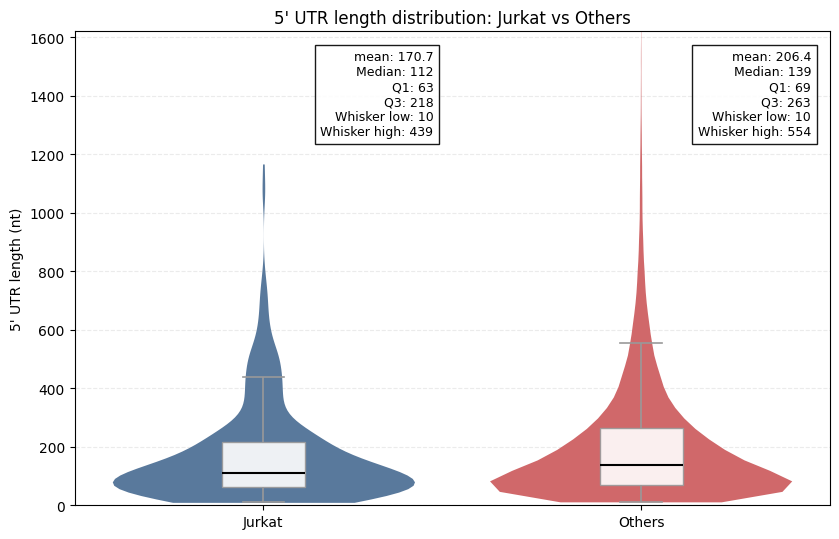

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Build a clean plotting frame without mutating jurkat/rest
plot_df = pd.concat(
    [
        jurkat[["5_UTR_len"]].assign(dataset="Jurkat"),
        rest[["5_UTR_len"]].assign(dataset="Others"),
    ],
    ignore_index=True,
).rename(columns={"5_UTR_len": "utr5_len"})

plot_df["utr5_len"] = pd.to_numeric(plot_df["utr5_len"], errors="coerce")
plot_df = plot_df.dropna(subset=["utr5_len"])

order = plot_df.groupby("dataset")["utr5_len"].median().sort_values().index.tolist()
# Compute summary including quartiles
grouped = plot_df.groupby("dataset")["utr5_len"]
summary = grouped.agg(["count", "mean", "median"]).copy()
summary['q1'] = grouped.quantile(0.25)
summary['q3'] = grouped.quantile(0.75)
# compute whisker endpoints consistent with boxplot (IQR 1.5 rule)
def _whiskers(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    vals = s[(s >= lo) & (s <= hi)]
    if vals.empty:
        return pd.Series({'low': s.min(), 'high': s.max()})
    return pd.Series({'low': vals.min(), 'high': vals.max()})
wh = grouped.apply(_whiskers).unstack()
summary['whisker_low'] = wh['low']
summary['whisker_high'] = wh['high']
summary = summary.loc[order]
print(summary[['count','mean','median','q1','q3','whisker_low','whisker_high']].round(1))

palette = {"Jurkat": "#4E79A7", "Others": "#E15759"}

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.violinplot(
    data=plot_df,
    x="dataset",
    y="utr5_len",
    hue="dataset",
    order=order,
    hue_order=order,
    palette=palette,
    inner=None,
    cut=0,
    linewidth=0,
    dodge=False,
    legend=False,
    ax=ax,
)
sns.boxplot(
    data=plot_df,
    x="dataset",
    y="utr5_len",
    order=order,
    width=0.22,
    showfliers=False,
    color="white",
    boxprops={"alpha": 0.9},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
    medianprops={"color": "black", "linewidth": 1.5},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("5' UTR length (nt)")
ax.set_title("5' UTR length distribution: Jurkat vs Others")
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

upper = float(plot_df["utr5_len"].quantile(0.995))
ax.set_ylim(0, upper * 1.28)

# Draw a compact legend box at the top-right of each group's region with mean/median/Q1/Q3 and whiskers
top = ax.get_ylim()[1]
y_pos = top * 0.96
for i, label in enumerate(order):
    stats = summary.loc[label]
    legend_text = (f"mean: {stats['mean']:.1f}\n"
                   f"Median: {int(stats['median'])}\n"
                   f"Q1: {int(stats['q1'])}\n"
                   f"Q3: {int(stats['q3'])}\n"
                   f"Whisker low: {int(stats['whisker_low'])}\n"
                   f"Whisker high: {int(stats['whisker_high'])}")
    ax.text(
        i + 0.45,
        y_pos,
        legend_text,
        ha="right",
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9, "pad": 4},
    )

plt.tight_layout()
plt.show()

         count   mean  median   q1      q3  whisker_low  whisker_high
dataset                                                              
Jurkat     495  995.3     0.0  0.0  1264.5          0.0        3142.0
Others   18411  904.5    89.0  0.0  1139.0          0.0        2846.0


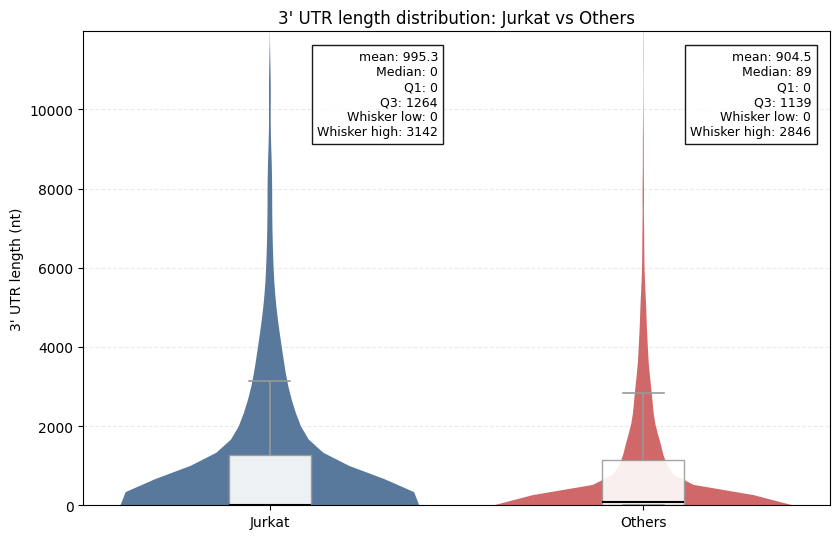

In [ ]:

# Build a clean plotting frame without mutating jurkat/rest
plot_df = pd.concat(
    [
        jurkat[["3_UTR_len"]].assign(dataset="Jurkat"),
        rest[["3_UTR_len"]].assign(dataset="Others"),
    ],
    ignore_index=True,
).rename(columns={"3_UTR_len": "utr3_len"})

plot_df["utr3_len"] = pd.to_numeric(plot_df["utr3_len"], errors="coerce")
plot_df = plot_df.dropna(subset=["utr3_len"])

# Keep Jurkat on the left
order = ["Jurkat", "Others"]

# Compute summary including quartiles
grouped = plot_df.groupby("dataset")["utr3_len"]
summary = grouped.agg(["count", "mean", "median"]).copy()
summary['q1'] = grouped.quantile(0.25)
summary['q3'] = grouped.quantile(0.75)
# compute whisker endpoints consistent with boxplot (IQR 1.5 rule)
def _whiskers(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    vals = s[(s >= lo) & (s <= hi)]
    if vals.empty:
        return pd.Series({'low': s.min(), 'high': s.max()})
    return pd.Series({'low': vals.min(), 'high': vals.max()})
wh = grouped.apply(_whiskers).unstack()
summary['whisker_low'] = wh['low']
summary['whisker_high'] = wh['high']
summary = summary.reindex(order)
print(summary[['count','mean','median','q1','q3','whisker_low','whisker_high']].round(1))

palette = {"Jurkat": "#4E79A7", "Others": "#E15759"}

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.violinplot(
    data=plot_df,
    x="dataset",
    y="utr3_len",
    hue="dataset",
    order=order,
    hue_order=order,
    palette=palette,
    inner=None,
    cut=0,
    linewidth=0,
    dodge=False,
    legend=False,
    ax=ax,
)
sns.boxplot(
    data=plot_df,
    x="dataset",
    y="utr3_len",
    order=order,
    width=0.22,
    showfliers=False,
    color="white",
    boxprops={"alpha": 0.9},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
    medianprops={"color": "black", "linewidth": 1.5},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("3' UTR length (nt)")
ax.set_title("3' UTR length distribution: Jurkat vs Others")
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

upper = float(plot_df["utr3_len"].quantile(0.995))
ax.set_ylim(0, upper * 1.28)

# Draw a compact legend box at the top-right of each group's region with mean/median/Q1/Q3 and whiskers
top = ax.get_ylim()[1]
y_pos = top * 0.96
for i, label in enumerate(order):
    stats = summary.loc[label]
    legend_text = (f"mean: {stats['mean']:.1f}\n"
                   f"Median: {int(stats['median'])}\n"
                   f"Q1: {int(stats['q1'])}\n"
                   f"Q3: {int(stats['q3'])}\n"
                   f"Whisker low: {int(stats['whisker_low'])}\n"
                   f"Whisker high: {int(stats['whisker_high'])}")
    ax.text(
        i + 0.45,
        y_pos,
        legend_text,
        ha="right",
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9, "pad": 4},
    )

plt.tight_layout()
plt.show()

         count    mean  median     q1      q3  whisker_low  whisker_high
dataset                                                                 
Jurkat     235  2096.6  1327.0  407.5  2713.0         35.0        6154.0
Others    9639  1727.6  1050.0  392.0  2362.0          3.0        5305.0


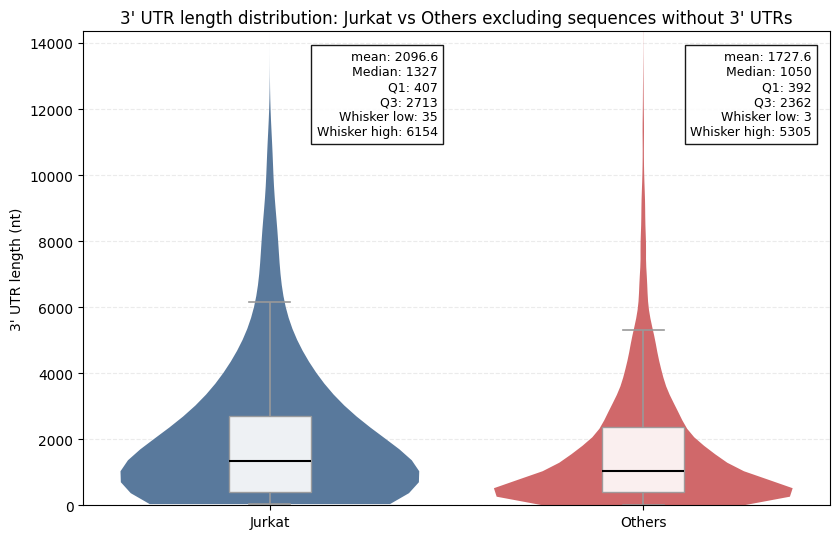

In [22]:
plot_df = pd.concat(
    [
        rest.loc[rest["3_UTR_len"] > 0, ["3_UTR_len"]].assign(dataset="Others"),
        jurkat.loc[jurkat["3_UTR_len"] > 0, ["3_UTR_len"]].assign(dataset="Jurkat"),
        
    ],
    ignore_index=True,
).rename(columns={"3_UTR_len": "utr3_len"})

plot_df["utr3_len"] = pd.to_numeric(plot_df["utr3_len"], errors="coerce")
plot_df = plot_df.dropna(subset=["utr3_len"])

# Keep Jurkat on the left
order = ["Jurkat", "Others"]

# Compute summary including quartiles
grouped = plot_df.groupby("dataset")["utr3_len"]
summary = grouped.agg(["count", "mean", "median"]).copy()
summary['q1'] = grouped.quantile(0.25)
summary['q3'] = grouped.quantile(0.75)
# compute whisker endpoints consistent with boxplot (IQR 1.5 rule)
def _whiskers(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    vals = s[(s >= lo) & (s <= hi)]
    if vals.empty:
        return pd.Series({'low': s.min(), 'high': s.max()})
    return pd.Series({'low': vals.min(), 'high': vals.max()})
wh = grouped.apply(_whiskers).unstack()
summary['whisker_low'] = wh['low']
summary['whisker_high'] = wh['high']
summary = summary.reindex(order)
print(summary[['count','mean','median','q1','q3','whisker_low','whisker_high']].round(1))

palette = {"Jurkat": "#4E79A7", "Others": "#E15759"}

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.violinplot(
    data=plot_df,
    x="dataset",
    y="utr3_len",
    hue="dataset",
    order=order,
    hue_order=order,
    palette=palette,
    inner=None,
    cut=0,
    linewidth=0,
    dodge=False,
    legend=False,
    ax=ax,
)
sns.boxplot(
    data=plot_df,
    x="dataset",
    y="utr3_len",
    order=order,
    width=0.22,
    showfliers=False,
    color="white",
    boxprops={"alpha": 0.9},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
    medianprops={"color": "black", "linewidth": 1.5},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("3' UTR length (nt)")
ax.set_title("3' UTR length distribution: Jurkat vs Others excluding sequences without 3' UTRs")
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

upper = float(plot_df["utr3_len"].quantile(0.995))
ax.set_ylim(0, upper * 1.28)

# Draw a compact legend box at the top-right of each group's region with mean/median/Q1/Q3 and whiskers
top = ax.get_ylim()[1]
y_pos = top * 0.96
for i, label in enumerate(order):
    stats = summary.loc[label]
    legend_text = (f"mean: {stats['mean']:.1f}\n"
                   f"Median: {int(stats['median'])}\n"
                   f"Q1: {int(stats['q1'])}\n"
                   f"Q3: {int(stats['q3'])}\n"
                   f"Whisker low: {int(stats['whisker_low'])}\n"
                   f"Whisker high: {int(stats['whisker_high'])}")
    ax.text(
        i + 0.45,
        y_pos,
        legend_text,
        ha="right",
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9, "pad": 4},
    )

plt.tight_layout()
plt.show()

--- 5' UTR GC Summary ---
         count   mean  median     q1     q3  whisker_low  whisker_high
dataset                                                               
Others   18411  0.637   0.645  0.557  0.727        0.303         0.939
Jurkat     495  0.665   0.667  0.594  0.741        0.373         0.938

--- 3' UTR GC Summary ---
         count   mean  median     q1     q3  whisker_low  whisker_high
dataset                                                               
Others    9639  0.438   0.425  0.354  0.516        0.130         0.759
Jurkat     235  0.444   0.448  0.359  0.518        0.171         0.688


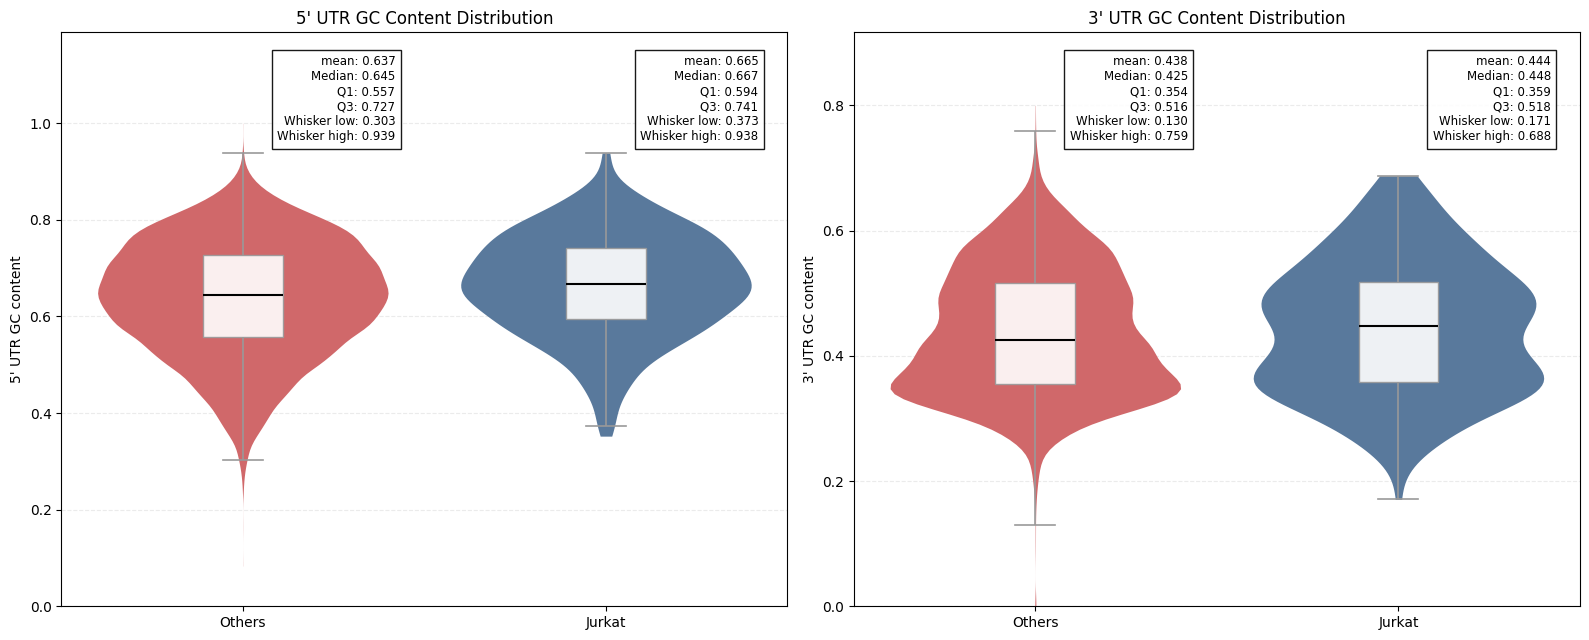

In [ ]:

# --- 5' UTR GC Content Dataset ---
plot_df_5gc = pd.concat(
    [
        jurkat[["5_UTR_GC"]].assign(dataset="Jurkat"),
        rest[["5_UTR_GC"]].assign(dataset="Others"),
    ],
    ignore_index=True,
).rename(columns={"5_UTR_GC": "utr5_gc"})

plot_df_5gc["utr5_gc"] = pd.to_numeric(plot_df_5gc["utr5_gc"], errors="coerce")
plot_df_5gc = plot_df_5gc.dropna(subset=["utr5_gc"])

# --- 3' UTR GC Content Dataset ---
plot_df_3gc = pd.concat(
    [
        jurkat[["3_UTR_GC"]].assign(dataset="Jurkat"),
        rest[["3_UTR_GC"]].assign(dataset="Others"),
    ],
    ignore_index=True,
).rename(columns={"3_UTR_GC": "utr3_gc"})

plot_df_3gc["utr3_gc"] = pd.to_numeric(plot_df_3gc["utr3_gc"], errors="coerce")
plot_df_3gc = plot_df_3gc.dropna(subset=["utr3_gc"])


# ==============================================================================
# 2. STATS & WHISKER CALCULATIONS
# ==============================================================================

def compute_summary_stats(df, value_col, group_order):
    grouped = df.groupby("dataset")[value_col]
    summary = grouped.agg(["count", "mean", "median"]).copy()
    summary['q1'] = grouped.quantile(0.25)
    summary['q3'] = grouped.quantile(0.75)
    
    def _whiskers(s):
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
        vals = s[(s >= lo) & (s <= hi)]
        if vals.empty:
            return pd.Series({'low': s.min(), 'high': s.max()})
        return pd.Series({'low': vals.min(), 'high': vals.max()})
        
    wh = grouped.apply(_whiskers).unstack()
    summary['whisker_low'] = wh['low']
    summary['whisker_high'] = wh['high']
    return summary.reindex(group_order)

# Set group orderings independently based on median values
order_5gc = plot_df_5gc.groupby("dataset")["utr5_gc"].median().sort_values().index.tolist()
order_3gc = plot_df_3gc.groupby("dataset")["utr3_gc"].median().sort_values().index.tolist()

summary_5gc = compute_summary_stats(plot_df_5gc, "utr5_gc", order_5gc)
summary_3gc = compute_summary_stats(plot_df_3gc, "utr3_gc", order_3gc)

# Console printouts for sanity checking
print("--- 5' UTR GC Summary ---")
print(summary_5gc[['count','mean','median','q1','q3','whisker_low','whisker_high']].round(3))
print("\n--- 3' UTR GC Summary ---")
print(summary_3gc[['count','mean','median','q1','q3','whisker_low','whisker_high']].round(3))


# ==============================================================================
# 3. PLOTTING SIDE-BY-SIDE
# ==============================================================================

palette = {"Jurkat": "#4E79A7", "Others": "#E15759"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

# ------------------------------------------------------------------------------
# Left Subplot: 5' UTR GC Content (ax1)
# ------------------------------------------------------------------------------
sns.violinplot(
    data=plot_df_5gc, x="dataset", y="utr5_gc", hue="dataset",
    order=order_5gc, hue_order=order_5gc, palette=palette,
    inner=None, cut=0, linewidth=0, dodge=False, legend=False, ax=ax1
)
sns.boxplot(
    data=plot_df_5gc, x="dataset", y="utr5_gc", order=order_5gc,
    width=0.22, showfliers=False, color="white", boxprops={"alpha": 0.9},
    whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2},
    medianprops={"color": "black", "linewidth": 1.5}, ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel("5' UTR GC content")
ax1.set_title("5' UTR GC Content Distribution")
ax1.grid(axis="y", linestyle="--", alpha=0.25)
ax1.set_axisbelow(True)

upper_5gc = float(plot_df_5gc["utr5_gc"].quantile(0.995))
ax1.set_ylim(0, upper_5gc * 1.35)

# Text overlay for Left Plot
top_5gc = ax1.get_ylim()[1]
for i, label in enumerate(order_5gc):
    stats = summary_5gc.loc[label]
    legend_text = (f"mean: {stats['mean']:.3f}\n"
                   f"Median: {stats['median']:.3f}\n"
                   f"Q1: {stats['q1']:.3f}\n"
                   f"Q3: {stats['q3']:.3f}\n"
                   f"Whisker low: {stats['whisker_low']:.3f}\n"
                   f"Whisker high: {stats['whisker_high']:.3f}")
    ax1.text(
        i + 0.42, top_5gc * 0.96, legend_text, ha="right", va="top", fontsize=8.5,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9, "pad": 4}
    )

# ------------------------------------------------------------------------------
# Right Subplot: 3' UTR GC Content (ax2)
# ------------------------------------------------------------------------------
sns.violinplot(
    data=plot_df_3gc, x="dataset", y="utr3_gc", hue="dataset",
    order=order_3gc, hue_order=order_3gc, palette=palette,
    inner=None, cut=0, linewidth=0, dodge=False, legend=False, ax=ax2
)
sns.boxplot(
    data=plot_df_3gc, x="dataset", y="utr3_gc", order=order_3gc,
    width=0.22, showfliers=False, color="white", boxprops={"alpha": 0.9},
    whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2},
    medianprops={"color": "black", "linewidth": 1.5}, ax=ax2
)

ax2.set_xlabel("")
ax2.set_ylabel("3' UTR GC content")
ax2.set_title("3' UTR GC Content Distribution")
ax2.grid(axis="y", linestyle="--", alpha=0.25)
ax2.set_axisbelow(True)

upper_3gc = float(plot_df_3gc["utr3_gc"].quantile(0.995))
ax2.set_ylim(0, upper_3gc * 1.35)

# Text overlay for Right Plot
top_3gc = ax2.get_ylim()[1]
for i, label in enumerate(order_3gc):
    stats = summary_3gc.loc[label]
    legend_text = (f"mean: {stats['mean']:.3f}\n"
                   f"Median: {stats['median']:.3f}\n"
                   f"Q1: {stats['q1']:.3f}\n"
                   f"Q3: {stats['q3']:.3f}\n"
                   f"Whisker low: {stats['whisker_low']:.3f}\n"
                   f"Whisker high: {stats['whisker_high']:.3f}")
    ax2.text(
        i + 0.42, top_3gc * 0.96, legend_text, ha="right", va="top", fontsize=8.5,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9, "pad": 4}
    )

# ==============================================================================
# 4. SHOW GRAPH
# ==============================================================================
plt.tight_layout()
plt.show()

--- 5' UTR GC Summary ---
         count   mean  median   q1    q3  whisker_low  whisker_high
dataset                                                            
Jurkat     495  6.133     0.0  0.0   7.5          0.0          18.0
Others   18411  9.361     5.0  0.0  11.0          0.0          27.0

--- 3' UTR GC Summary ---
         count     mean  median   q1     q3  whisker_low  whisker_high
dataset                                                               
Jurkat     495  111.572     0.0  0.0  113.0          0.0         281.0
Others   18411  103.980     5.0  0.0  115.0          0.0         287.0


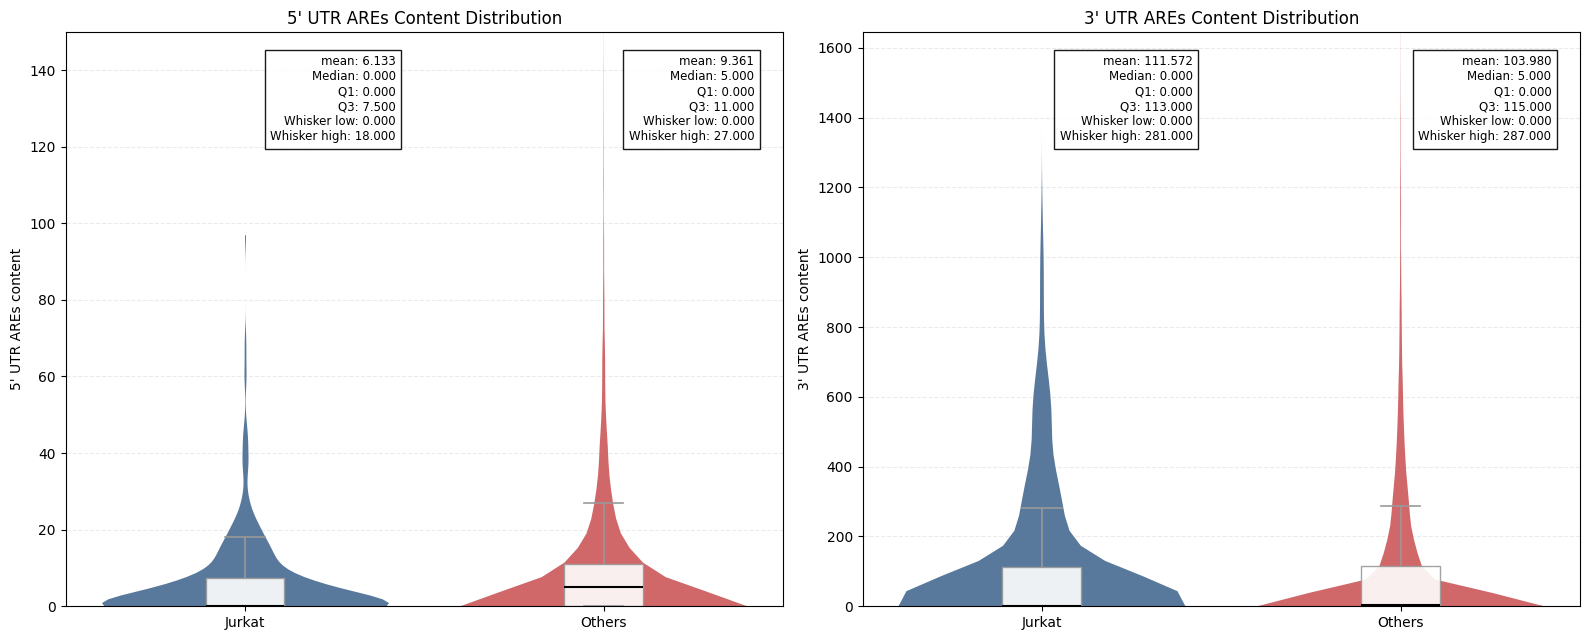

In [36]:
plot_df_5gc = pd.concat(
    [
        jurkat[["5_AREs"]].assign(dataset="Jurkat"),
        rest[["5_AREs"]].assign(dataset="Others"),
    ],
    ignore_index=True,
).rename(columns={"5_AREs": "utr5_ares"})

plot_df_5gc["utr5_ares"] = pd.to_numeric(plot_df_5gc["utr5_ares"], errors="coerce")
plot_df_5gc = plot_df_5gc.dropna(subset=["utr5_ares"])

# --- 3' UTR GC Content Dataset ---
plot_df_3gc = pd.concat(
    [
        jurkat[["3_AREs"]].assign(dataset="Jurkat"),
        rest[["3_AREs"]].assign(dataset="Others"),
    ],
    ignore_index=True,
).rename(columns={"3_AREs": "utr3_ares"})

plot_df_3gc["utr3_ares"] = pd.to_numeric(plot_df_3gc["utr3_ares"], errors="coerce")
plot_df_3gc = plot_df_3gc.dropna(subset=["utr3_ares"])


# ==============================================================================
# 2. STATS & WHISKER CALCULATIONS
# ==============================================================================

def compute_summary_stats(df, value_col, group_order):
    grouped = df.groupby("dataset")[value_col]
    summary = grouped.agg(["count", "mean", "median"]).copy()
    summary['q1'] = grouped.quantile(0.25)
    summary['q3'] = grouped.quantile(0.75)
    
    def _whiskers(s):
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
        vals = s[(s >= lo) & (s <= hi)]
        if vals.empty:
            return pd.Series({'low': s.min(), 'high': s.max()})
        return pd.Series({'low': vals.min(), 'high': vals.max()})
        
    wh = grouped.apply(_whiskers).unstack()
    summary['whisker_low'] = wh['low']
    summary['whisker_high'] = wh['high']
    return summary.reindex(group_order)

# Set group orderings independently based on median values
order_5gc = plot_df_5gc.groupby("dataset")["utr5_ares"].median().sort_values().index.tolist()
order_3gc = plot_df_3gc.groupby("dataset")["utr3_ares"].median().sort_values().index.tolist()

summary_5gc = compute_summary_stats(plot_df_5gc, "utr5_ares", order_5gc)
summary_3gc = compute_summary_stats(plot_df_3gc, "utr3_ares", order_3gc)

# Console printouts for sanity checking
print("--- 5' UTR GC Summary ---")
print(summary_5gc[['count','mean','median','q1','q3','whisker_low','whisker_high']].round(3))
print("\n--- 3' UTR GC Summary ---")
print(summary_3gc[['count','mean','median','q1','q3','whisker_low','whisker_high']].round(3))


# ==============================================================================
# 3. PLOTTING SIDE-BY-SIDE
# ==============================================================================

palette = {"Jurkat": "#4E79A7", "Others": "#E15759"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

# ------------------------------------------------------------------------------
# Left Subplot: 5' UTR GC Content (ax1)
# ------------------------------------------------------------------------------
sns.violinplot(
    data=plot_df_5gc, x="dataset", y="utr5_ares", hue="dataset",
    order=order_5gc, hue_order=order_5gc, palette=palette,
    inner=None, cut=0, linewidth=0, dodge=False, legend=False, ax=ax1
)
sns.boxplot(
    data=plot_df_5gc, x="dataset", y="utr5_ares", order=order_5gc,
    width=0.22, showfliers=False, color="white", boxprops={"alpha": 0.9},
    whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2},
    medianprops={"color": "black", "linewidth": 1.5}, ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel("5' UTR AREs content")
ax1.set_title("5' UTR AREs Content Distribution")
ax1.grid(axis="y", linestyle="--", alpha=0.25)
ax1.set_axisbelow(True)

upper_5gc = float(plot_df_5gc["utr5_ares"].quantile(0.995))
ax1.set_ylim(0, upper_5gc * 1.35)

# Text overlay for Left Plot
top_5gc = ax1.get_ylim()[1]
for i, label in enumerate(order_5gc):
    stats = summary_5gc.loc[label]
    legend_text = (f"mean: {stats['mean']:.3f}\n"
                   f"Median: {stats['median']:.3f}\n"
                   f"Q1: {stats['q1']:.3f}\n"
                   f"Q3: {stats['q3']:.3f}\n"
                   f"Whisker low: {stats['whisker_low']:.3f}\n"
                   f"Whisker high: {stats['whisker_high']:.3f}")
    ax1.text(
        i + 0.42, top_5gc * 0.96, legend_text, ha="right", va="top", fontsize=8.5,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9, "pad": 4}
    )

# ------------------------------------------------------------------------------
# Right Subplot: 3' UTR AREs Content (ax2)
# ------------------------------------------------------------------------------
sns.violinplot(
    data=plot_df_3gc, x="dataset", y="utr3_ares", hue="dataset",
    order=order_3gc, hue_order=order_3gc, palette=palette,
    inner=None, cut=0, linewidth=0, dodge=False, legend=False, ax=ax2
)
sns.boxplot(
    data=plot_df_3gc, x="dataset", y="utr3_ares", order=order_3gc,
    width=0.22, showfliers=False, color="white", boxprops={"alpha": 0.9},
    whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2},
    medianprops={"color": "black", "linewidth": 1.5}, ax=ax2
)

ax2.set_xlabel("")
ax2.set_ylabel("3' UTR AREs content")
ax2.set_title("3' UTR AREs Content Distribution")
ax2.grid(axis="y", linestyle="--", alpha=0.25)
ax2.set_axisbelow(True)

upper_3gc = float(plot_df_3gc["utr3_ares"].quantile(0.995))
ax2.set_ylim(0, upper_3gc * 1.35)

# Text overlay for Right Plot
top_3gc = ax2.get_ylim()[1]
for i, label in enumerate(order_3gc):
    stats = summary_3gc.loc[label]
    legend_text = (f"mean: {stats['mean']:.3f}\n"
                   f"Median: {stats['median']:.3f}\n"
                   f"Q1: {stats['q1']:.3f}\n"
                   f"Q3: {stats['q3']:.3f}\n"
                   f"Whisker low: {stats['whisker_low']:.3f}\n"
                   f"Whisker high: {stats['whisker_high']:.3f}")
    ax2.text(
        i + 0.42, top_3gc * 0.96, legend_text, ha="right", va="top", fontsize=8.5,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9, "pad": 4}
    )

# ==============================================================================
# 4. SHOW GRAPH
# ==============================================================================
plt.tight_layout()
plt.show()

/tmp/ipykernel_288660/714398294.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_288660/714398294.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")


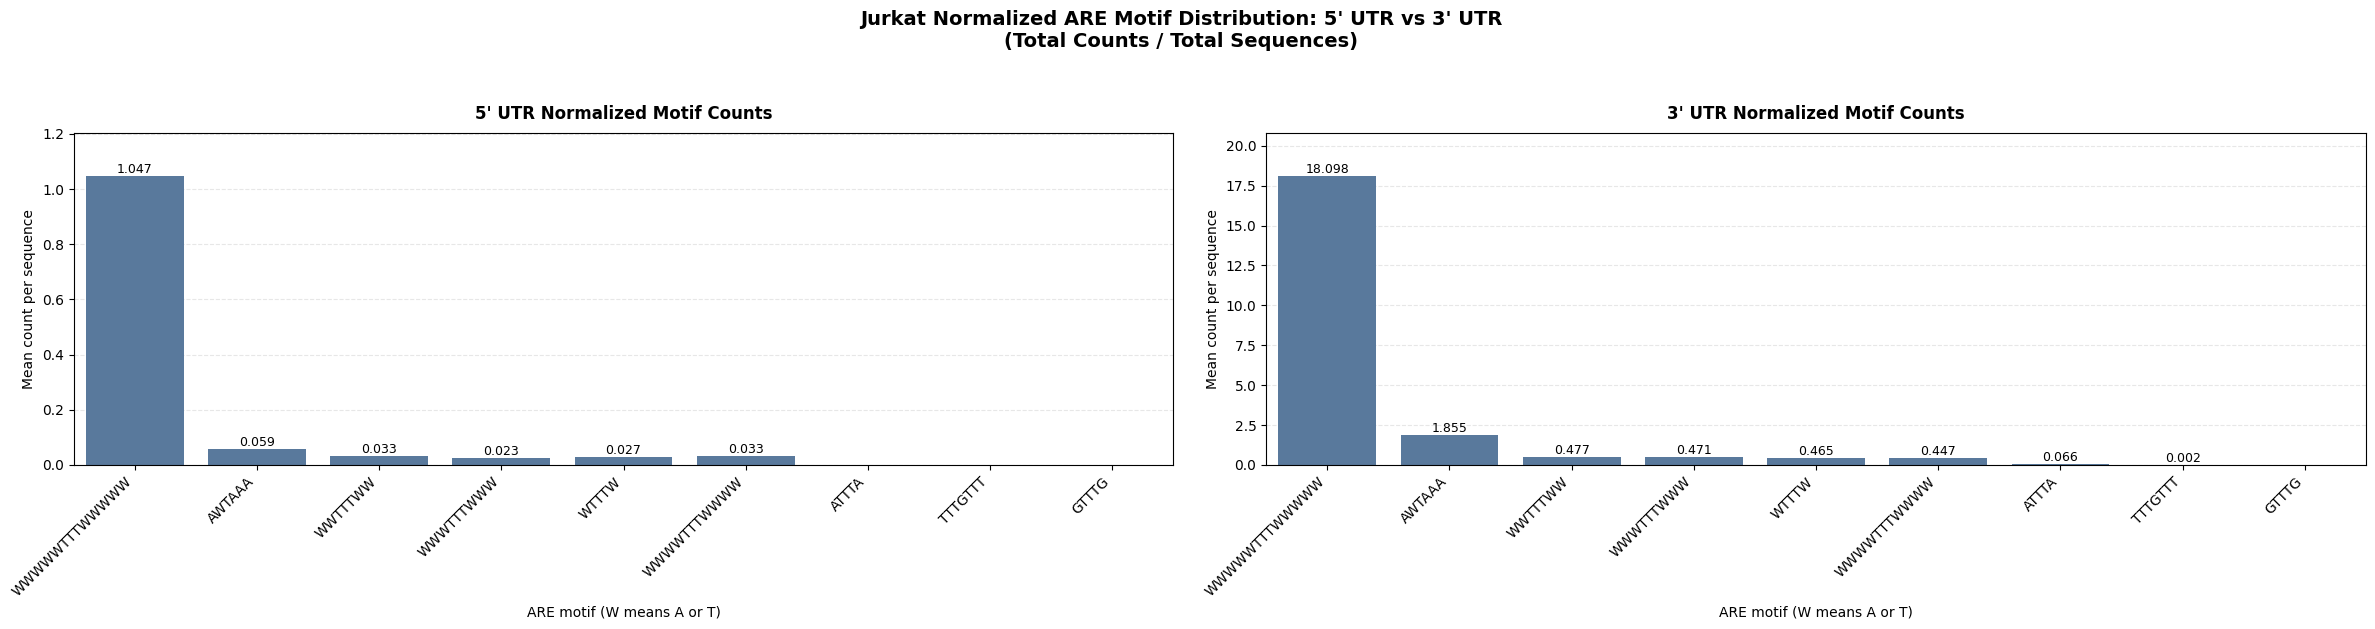

Region            3' UTR    5' UTR
ARE                               
WWWWWTTTWWWWW  18.097656  1.046875
AWTAAA          1.855469  0.058594
WWTTTWW         0.476562  0.033203
WWWTTTWWW       0.470703  0.023438
WTTTW           0.464844  0.027344
WWWWTTTWWWW     0.447266  0.033203
ATTTA           0.066406  0.000000
TTTGTTT         0.001953  0.000000
GTTTG           0.000000  0.000000


In [52]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Keep your exact counting logic function completely unchanged
def count_motifs_no_overlap(sequence, motif_patterns):
    if not isinstance(sequence, str) or not sequence:
        return {m: 0 for m in motif_patterns.keys()}

    seq = sequence.upper()
    candidates = []

    for motif_name, pattern in motif_patterns.items():
        lookahead_pat = re.compile(f"(?=({pattern}))", flags=re.IGNORECASE)
        for m in lookahead_pat.finditer(seq):
            matched = m.group(1)
            start = m.start(1)
            end = m.end(1)
            candidates.append((start, end, motif_name, len(matched)))

    candidates.sort(key=lambda x: (-x[3], x[0]))

    occupied = np.zeros(len(seq), dtype=bool)
    counts = {m: 0 for m in motif_patterns.keys()}

    for start, end, motif_name, _ in candidates:
        if not occupied[start:end].any():
            counts[motif_name] += 1
            occupied[start:end] = True

    return counts


# ==============================================================================
# 1. PARSE REGIONS & NORMALIZE BY ROW COUNT
# ==============================================================================
records = []
target_regions = ["5' UTR", "3' UTR"]

for col in target_regions:
    # Track the exact total number of valid sequence entries/rows for this column
    seq_series = jurkat[col].fillna("").astype(str)
    total_rows = len(seq_series)

    # Fallback to avoid division-by-zero errors on empty slices
    if total_rows == 0:
        total_rows = 1

    # Initialize raw counter
    region_totals = {m: 0 for m in motifs.keys()}

    for seq in seq_series:
        c = count_motifs_no_overlap(seq, motifs)
        for motif_name, value in c.items():
            region_totals[motif_name] += value

    # Normalize values by the dataset's total row count
    for motif_name, total_count in region_totals.items():
        normalized_val = total_count / total_rows
        records.append(
            {
                "Region": col,
                "ARE": motif_name,
                "raw_count": total_count,
                "normalized_count": normalized_val,
            }
        )

# Create plotting dataframe
plot_df = pd.DataFrame(records)

# Synchronize categorical X-axis sequence based on 3' UTR normalized abundance
order_ranking = (
    plot_df[plot_df["Region"] == "3' UTR"]
    .sort_values(by="normalized_count", ascending=False)["ARE"]
    .tolist()
)


# ==============================================================================
# 2. PLOTTING SIDE-BY-SIDE
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 6), sharey=False)

# --- Left Plot: 5' UTR ---
df_5utr = plot_df[plot_df["Region"] == "5' UTR"]
sns.barplot(
    data=df_5utr,
    x="ARE",
    y="normalized_count",
    order=order_ranking,
    color="#4E79A7",
    ax=ax1,
)
ax1.set_title("5' UTR Normalized Motif Counts", weight="bold", fontsize=12, pad=10)
ax1.set_xlabel("ARE motif (W means A or T)", fontsize=10)
ax1.set_ylabel("Mean count per sequence", fontsize=10)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.set_axisbelow(True)

# Annotate floating point density numbers above bars
for p in ax1.patches:
    val = p.get_height()
    if val > 0:
        ax1.text(
            p.get_x() + p.get_width() / 2,
            val,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
ax1.set_ylim(0, df_5utr["normalized_count"].max() * 1.15)


# --- Right Plot: 3' UTR ---
df_3utr = plot_df[plot_df["Region"] == "3' UTR"]
sns.barplot(
    data=df_3utr,
    x="ARE",
    y="normalized_count",
    order=order_ranking,
    color="#4E79A7",
    ax=ax2,
)
ax2.set_title("3' UTR Normalized Motif Counts", weight="bold", fontsize=12, pad=10)
ax2.set_xlabel("ARE motif (W means A or T)", fontsize=10)
ax2.set_ylabel("Mean count per sequence", fontsize=10)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.set_axisbelow(True)

# Annotate floating point density numbers above bars
for p in ax2.patches:
    val = p.get_height()
    if val > 0:
        ax2.text(
            p.get_x() + p.get_width() / 2,
            val,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
ax2.set_ylim(0, df_3utr["normalized_count"].max() * 1.15)


# ==============================================================================
# 3. DISPLAY
# ==============================================================================
plt.suptitle(
    "Jurkat Normalized ARE Motif Distribution: 5' UTR vs 3' UTR\n(Total Counts / Total Sequences)",
    weight="bold",
    fontsize=14,
    y=1.04,
)
plt.tight_layout()
plt.show()

# Print normalized summary table for terminal check
print(
    plot_df.pivot(
        index="ARE", columns="Region", values="normalized_count"
    ).reindex(order_ranking)
)

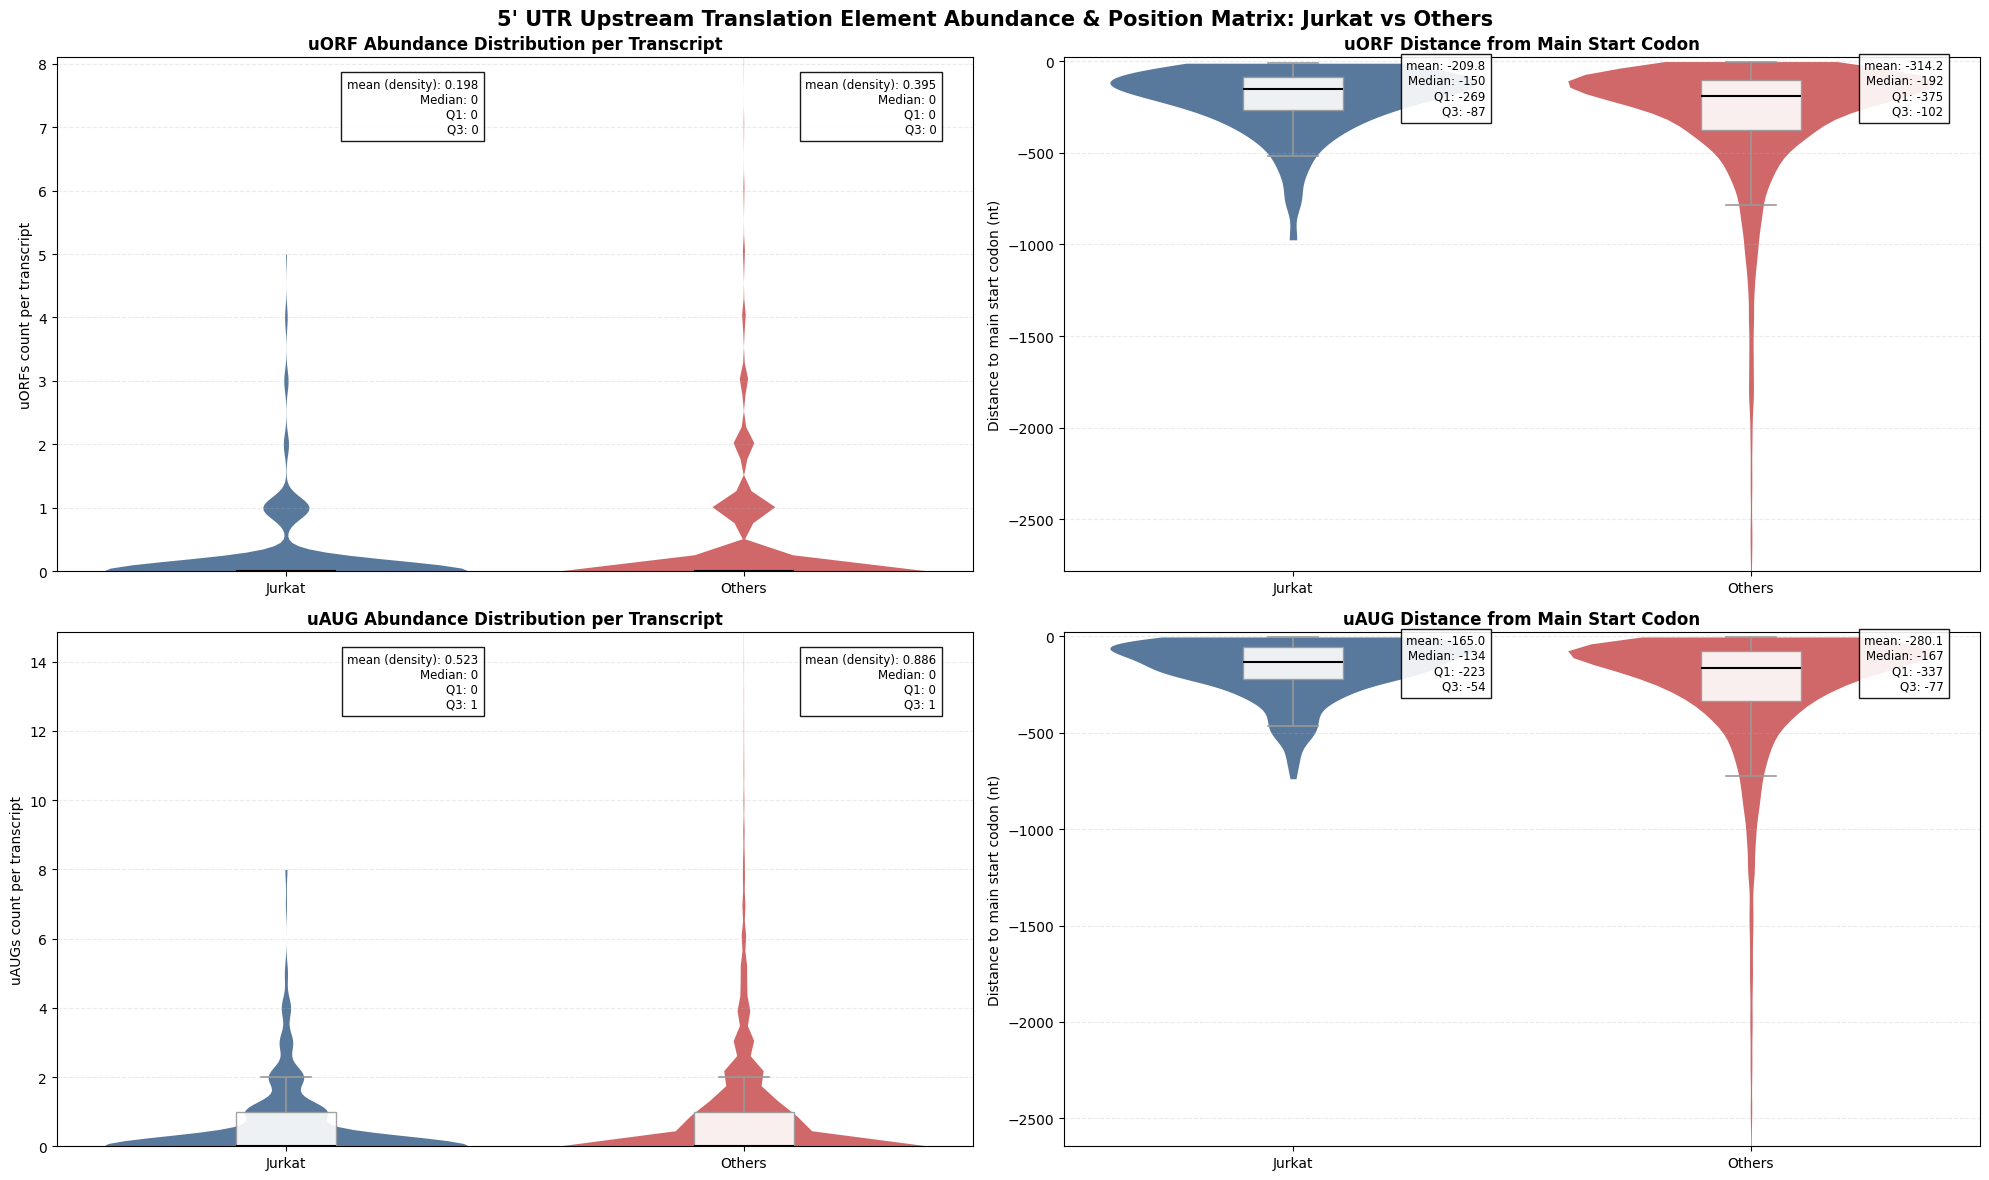

In [56]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==============================================================================
# 1. UPGRADED FEATURE EXTRACTION FUNCTION (Symmetrical Counting)
# ==============================================================================
def extract_utr_features(dataframe, dataset_label):
    """
    Parses 5' UTR sequences to extract both uORF and uAUG metrics.
    Tracks exact counts of both features per transcript for consistent abundance plotting.
    """
    extracted_features = []
    per_transcript_counts = []
    valid_row_count = 0 
    
    for idx, row in dataframe.iterrows():
        seq = str(row.get("5_UTR", "")).upper()
        if not seq or seq in ["NAN", "NONE"]:
            continue
            
        valid_row_count += 1
        utr_len = len(seq)
        t_id = row.get('transcript_id', idx)
        
        uorf_count_this_transcript = 0
        uaug_count_this_transcript = 0
        
        # Find all upstream ATG instances
        for match in re.finditer('ATG', seq):
            start_pos = match.start()
            relative_dist = start_pos - utr_len
            
            if relative_dist % 3 == 0:
                feature_type = 'uORF'
                uorf_count_this_transcript += 1
            else:
                feature_type = 'uAUG'
                uaug_count_this_transcript += 1
                    
            extracted_features.append({
                'transcript_id': t_id,
                'dataset': dataset_label,
                'feature_type': feature_type,
                'relative_distance': relative_dist
            })
            
        # Record the per-transcript abundance arrays (including zero-counts)
        per_transcript_counts.append({
            'transcript_id': t_id,
            'dataset': dataset_label,
            'uorf_count': uorf_count_this_transcript,
            'uaug_count': uaug_count_this_transcript
        })
            
    return pd.DataFrame(extracted_features), pd.DataFrame(per_transcript_counts), max(1, valid_row_count)


# ==============================================================================
# 2. RUN EXTRACTION AND DATA PROCESSING
# ==============================================================================
jurkat_feat, jurkat_counts, _ = extract_utr_features(jurkat, "Jurkat")
rest_feat, rest_counts, _ = extract_utr_features(rest, "Others")

# Combine datasets vertically
combined_features = pd.concat([jurkat_feat, rest_feat], ignore_index=True)
combined_counts = pd.concat([jurkat_counts, rest_counts], ignore_index=True)

# Split spatial features for the right-hand distance plots
df_uorf_dist = combined_features[combined_features["feature_type"] == "uORF"]
df_uaug_dist = combined_features[combined_features["feature_type"] == "uAUG"]


# ==============================================================================
# 3. STATS & WHISKER CALCULATIONS HELPER
# ==============================================================================
def compute_summary_stats(df, value_col, group_order):
    clean_df = df.dropna(subset=[value_col])
    grouped = clean_df.groupby("dataset")[value_col]
    summary = grouped.agg(["count", "mean", "median"]).copy()
    summary['q1'] = grouped.quantile(0.25)
    summary['q3'] = grouped.quantile(0.75)
    
    def _whiskers(s):
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
        vals = s[(s >= lo) & (s <= hi)]
        if vals.empty:
            return pd.Series({'low': s.min(), 'high': s.max()})
        return pd.Series({'low': vals.min(), 'high': vals.max()})
        
    wh = grouped.apply(_whiskers).unstack()
    summary['whisker_low'] = wh['low']
    summary['whisker_high'] = wh['high']
    return summary.reindex(group_order)

order_groups = ["Jurkat", "Others"]

# Generate text summary statistics matrices
stats_uorf_counts = compute_summary_stats(combined_counts, "uorf_count", order_groups)
stats_uorf_dist   = compute_summary_stats(df_uorf_dist, "relative_distance", order_groups)
stats_uaug_counts = compute_summary_stats(combined_counts, "uaug_count", order_groups)
stats_uaug_dist   = compute_summary_stats(df_uaug_dist, "relative_distance", order_groups)


# ==============================================================================
# 4. PLOTTING THE 2x2 ANALYSIS MATRIX (Perfect Symmetrical Consistency)
# ==============================================================================
palette = {"Jurkat": "#4E79A7", "Others": "#E15759"}
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
ax = axes.flatten()

# ------------------------------------------------------------------------------
# Panel [0]: uORF Abundance Distribution (Top Left) - NOW UPDATED TO ABUNDANCE
# ------------------------------------------------------------------------------
sns.violinplot(data=combined_counts, x="dataset", y="uorf_count", hue="dataset", order=order_groups, hue_order=order_groups, palette=palette, inner=None, cut=0, linewidth=0, dodge=False, legend=False, ax=ax[0])
sns.boxplot(data=combined_counts, x="dataset", y="uorf_count", order=order_groups, width=0.22, showfliers=False, color="white", boxprops={"alpha": 0.9}, whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2}, medianprops={"color": "black", "linewidth": 1.5}, ax=ax[0])
ax[0].set_title("uORF Abundance Distribution per Transcript", weight="bold")
ax[0].set_ylabel("uORFs count per transcript")
ax[0].set_xlabel("")
ax[0].grid(axis="y", linestyle="--", alpha=0.25)

top_0 = float(combined_counts["uorf_count"].quantile(0.995)) * 1.35
ax[0].set_ylim(0, max(top_0, 5))
for i, label in enumerate(order_groups):
    stats = stats_uorf_counts.loc[label]
    legend_text = (f"mean (density): {stats['mean']:.3f}\n"
                   f"Median: {int(stats['median'])}\n"
                   f"Q1: {int(stats['q1'])}\n"
                   f"Q3: {int(stats['q3'])}")
    ax[0].text(i + 0.42, ax[0].get_ylim()[1] * 0.96, legend_text, ha="right", va="top", fontsize=8.5, bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9, "pad": 4})

# ------------------------------------------------------------------------------
# Panel [1]: uORF Distance from Start Codon (Top Right)
# ------------------------------------------------------------------------------
sns.violinplot(data=df_uorf_dist.dropna(subset=["relative_distance"]), x="dataset", y="relative_distance", hue="dataset", order=order_groups, hue_order=order_groups, palette=palette, inner=None, cut=0, linewidth=0, dodge=False, legend=False, ax=ax[1])
sns.boxplot(data=df_uorf_dist.dropna(subset=["relative_distance"]), x="dataset", y="relative_distance", order=order_groups, width=0.22, showfliers=False, color="white", boxprops={"alpha": 0.9}, whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2}, medianprops={"color": "black", "linewidth": 1.5}, ax=ax[1])
ax[1].set_title("uORF Distance from Main Start Codon", weight="bold")
ax[1].set_ylabel("Distance to main start codon (nt)")
ax[1].set_xlabel("")
ax[1].grid(axis="y", linestyle="--", alpha=0.25)

bottom_1 = float(df_uorf_dist["relative_distance"].quantile(0.005)) * 1.15
ax[1].set_ylim(bottom_1, 20)
for i, label in enumerate(order_groups):
    stats = stats_uorf_dist.loc[label]
    legend_text = (f"mean: {stats['mean']:.1f}\n"
                   f"Median: {int(stats['median'])}\n"
                   f"Q1: {int(stats['q1'])}\n"
                   f"Q3: {int(stats['q3'])}")
    ax[1].text(i + 0.42, 10, legend_text, ha="right", va="top", fontsize=8.5, bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9, "pad": 4})

# ------------------------------------------------------------------------------
# Panel [2]: uAUG Abundance Distribution (Bottom Left)
# ------------------------------------------------------------------------------
sns.violinplot(data=combined_counts, x="dataset", y="uaug_count", hue="dataset", order=order_groups, hue_order=order_groups, palette=palette, inner=None, cut=0, linewidth=0, dodge=False, legend=False, ax=ax[2])
sns.boxplot(data=combined_counts, x="dataset", y="uaug_count", order=order_groups, width=0.22, showfliers=False, color="white", boxprops={"alpha": 0.9}, whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2}, medianprops={"color": "black", "linewidth": 1.5}, ax=ax[2])
ax[2].set_title("uAUG Abundance Distribution per Transcript", weight="bold")
ax[2].set_ylabel("uAUGs count per transcript")
ax[2].set_xlabel("")
ax[2].grid(axis="y", linestyle="--", alpha=0.25)

top_2 = float(combined_counts["uaug_count"].quantile(0.995)) * 1.35
ax[2].set_ylim(0, max(top_2, 5))
for i, label in enumerate(order_groups):
    stats = stats_uaug_counts.loc[label]
    legend_text = (f"mean (density): {stats['mean']:.3f}\n"
                   f"Median: {int(stats['median'])}\n"
                   f"Q1: {int(stats['q1'])}\n"
                   f"Q3: {int(stats['q3'])}")
    ax[2].text(i + 0.42, ax[2].get_ylim()[1] * 0.96, legend_text, ha="right", va="top", fontsize=8.5, bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9, "pad": 4})

# ------------------------------------------------------------------------------
# Panel [3]: uAUG Distance from Start Codon (Bottom Right)
# ------------------------------------------------------------------------------
sns.violinplot(data=df_uaug_dist.dropna(subset=["relative_distance"]), x="dataset", y="relative_distance", hue="dataset", order=order_groups, hue_order=order_groups, palette=palette, inner=None, cut=0, linewidth=0, dodge=False, legend=False, ax=ax[3])
sns.boxplot(data=df_uaug_dist.dropna(subset=["relative_distance"]), x="dataset", y="relative_distance", order=order_groups, width=0.22, showfliers=False, color="white", boxprops={"alpha": 0.9}, whiskerprops={"linewidth": 1.2}, capprops={"linewidth": 1.2}, medianprops={"color": "black", "linewidth": 1.5}, ax=ax[3])
ax[3].set_title("uAUG Distance from Main Start Codon", weight="bold")
ax[3].set_ylabel("Distance to main start codon (nt)")
ax[3].set_xlabel("")
ax[3].grid(axis="y", linestyle="--", alpha=0.25)

bottom_3 = float(df_uaug_dist["relative_distance"].quantile(0.005)) * 1.15
ax[3].set_ylim(bottom_3, 20)
for i, label in enumerate(order_groups):
    stats = stats_uaug_dist.loc[label]
    legend_text = (f"mean: {stats['mean']:.1f}\n"
                   f"Median: {int(stats['median'])}\n"
                   f"Q1: {int(stats['q1'])}\n"
                   f"Q3: {int(stats['q3'])}")
    ax[3].text(i + 0.42, 10, legend_text, ha="right", va="top", fontsize=8.5, bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9, "pad": 4})

# ==============================================================================
# 5. RENDER SYSTEM PLOT
# ==============================================================================
plt.suptitle("5' UTR Upstream Translation Element Abundance & Position Matrix: Jurkat vs Others", weight="bold", fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

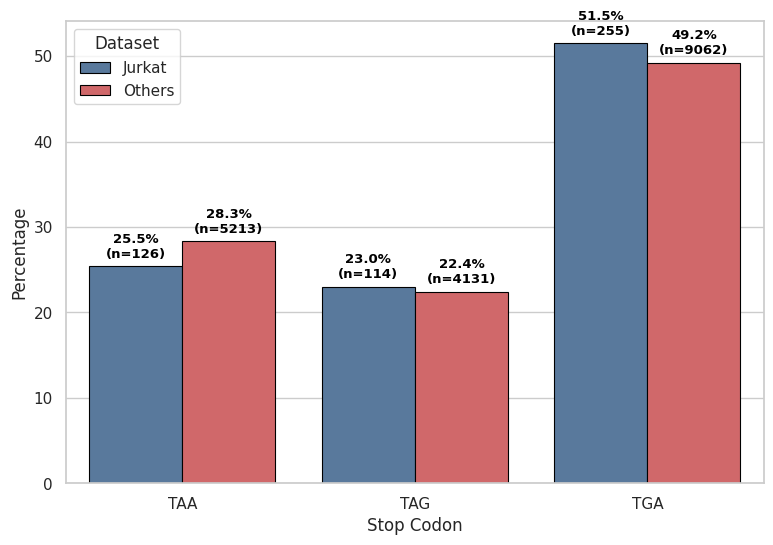

In [59]:
def process_stop_codons(dataframe, dataset_label):
    """Cleans stop codon entries and calculates their relative percentages."""
    # Ensure uppercase and drop missing values
    stops = dataframe["stop_codon"].dropna().str.upper()

    # Filter to ensure we only count standard canonical stop codons
    stops = stops[stops.isin(["TAA", "TAG", "TGA"])]

    # Calculate raw counts
    counts = stops.value_counts()

    # Ensure all three exist in the series index even if count is 0
    for codon in ["TAA", "TAG", "TGA"]:
        if codon not in counts:
            counts[codon] = 0

    # Reindex for order consistency
    counts = counts.reindex(["TAA", "TAG", "TGA"])

    # Convert to a relative percentage distribution
    total = counts.sum()
    percentages = (counts / (total if total > 0 else 1)) * 100

    # Build clean sub-dataframe
    return pd.DataFrame(
        {
            "Stop Codon": ["TAA", "TAG", "TGA"],
            "Percentage": percentages.values,
            "Count": counts.values,
            "Dataset": dataset_label,
        }
    )


# Process both datasets independently
jurkat_stops = process_stop_codons(jurkat, "Jurkat")
rest_stops = process_stop_codons(rest, "Others")

# Combine vertically for Seaborn grouping
combined_stops = pd.concat([jurkat_stops, rest_stops], ignore_index=True)


# ==============================================================================
# 2. PLOTTING THE COMPARISON
# ==============================================================================
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Color palette mapped specifically to your Group conditions
dataset_palette = {"Jurkat": "#4E79A7", "Others": "#E15759"}

ax = sns.barplot(
    data=combined_stops,
    x="Stop Codon",
    y="Percentage",
    hue="Dataset",
    palette=dataset_palette,
    edgecolor="black",
    linewidth=0.8,
)
# ------------------------------------------------------------------------------
# 3. FIXED CONTAINERS DATA LABELS (Matches Data 1:1 Without Index Shift Bugs)
# ------------------------------------------------------------------------------
# Split our data rows back out to match the visual order Seaborn draws the bars
jurkat_data = combined_stops[combined_stops["Dataset"] == "Jurkat"].reset_index(drop=True)
others_data = combined_stops[combined_stops["Dataset"] == "Others"].reset_index(drop=True)

# ax.containers[0] holds all Jurkat bars; ax.containers[1] holds all Others bars
for c_idx, container in enumerate(ax.containers):
    # Select the correct data slice based on the container group
    current_df = jurkat_data if c_idx == 0 else others_data
    
    for i, p in enumerate(container):
        height = p.get_height()
        
        # Only annotate if the bar has a real, non-zero height
        if height > 0:
            raw_count = current_df.iloc[i]["Count"]
            label_text = f"{height:.1f}%\n(n={int(raw_count)})"
            
            ax.annotate(
                label_text,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', 
                va='bottom',
                fontsize=9.5, 
                color='black',
                weight='semibold',
                xytext=(0, 4),
                textcoords='offset points'
            )

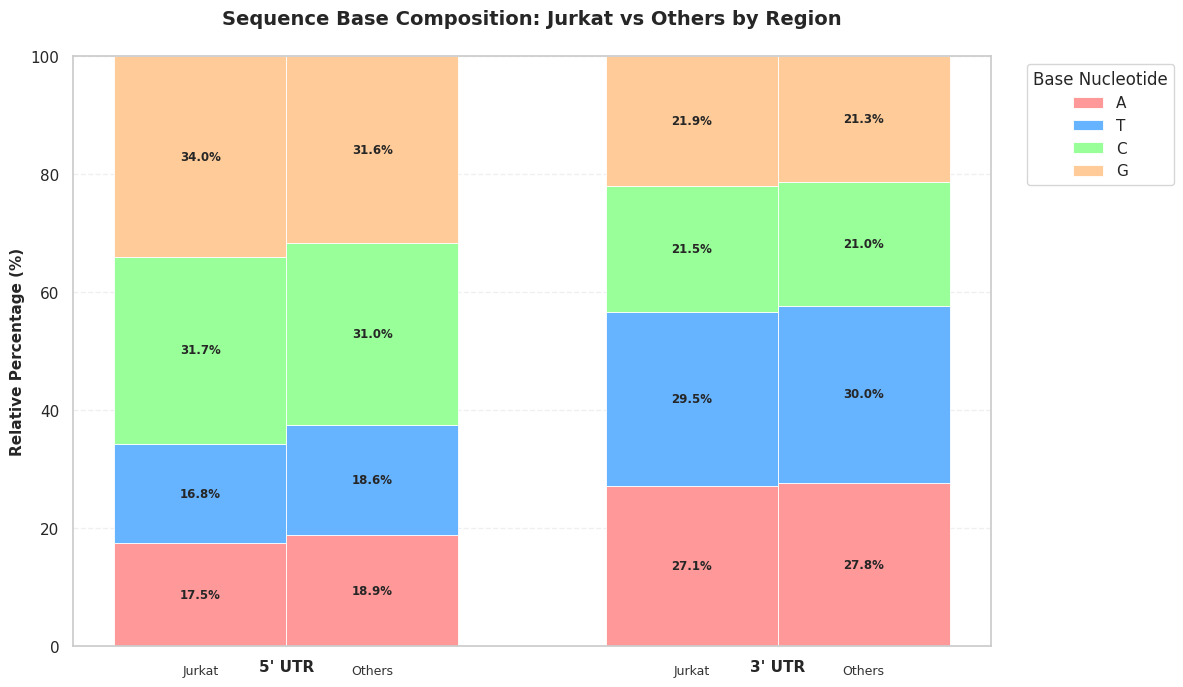

In [62]:

def calculate_base_composition(df, column_name):
    """Extracts all text sequences from a column and tallies A, T, C, G counts."""
    # Combine all sequences into one giant uppercase string, dropping NaNs
    all_seqs = "".join(df[column_name].dropna().astype(str)).upper()

    # Tally up standard base hits
    return [
        all_seqs.count("A"),
        all_seqs.count("T") or all_seqs.count("U"),  # Handles T or U (RNA/DNA)
        all_seqs.count("C"),
        all_seqs.count("G"),
    ]


# ==============================================================================
# 2. EXTRACT AND NORMALIZE DIRECTLY FROM YOUR DATAFRAMES
# ==============================================================================
regions_map = {
    "5' UTR": "5_UTR",
    "3' UTR": "3_UTR",
}

raw_data = {}

# Dynamically calculate total A/T/C/G counts for every target condition slice
for display_name, col_name in regions_map.items():
    if col_name in jurkat.columns:
        raw_data[(display_name, "Jurkat")] = calculate_base_composition(
            jurkat, col_name
        )
    else:
        raw_data[(display_name, "Jurkat")] = [0, 0, 0, 0]  # Fallback if empty

    if col_name in rest.columns:
        raw_data[(display_name, "Others")] = calculate_base_composition(
            rest, col_name
        )
    else:
        raw_data[(display_name, "Others")] = [0, 0, 0, 0]

# Structure raw dictionary output into a clean tracking Matrix
index = pd.MultiIndex.from_tuples(raw_data.keys(), names=["Region", "Dataset"])
df_composition = pd.DataFrame(
    raw_data.values(), index=index, columns=["A", "T", "C", "G"]
)

# Convert raw integer values into normalized row-by-row percentages (0-100%)
row_sums = df_composition.sum(axis=1)
normalized_df = df_composition.div(row_sums, axis=0) * 100


# ==============================================================================
# 3. PLOTTING CONFIGURATION
# ==============================================================================
regions = ["5' UTR", "3' UTR"]
datasets = ["Jurkat", "Others"]
bases = ["A", "T", "C", "G"]
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99'] 

plt.figure(figsize=(12, 7))
plt.rcParams.update(
    {"axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.3}
)

bar_width = 0.35
x_indexes = np.arange(len(regions))

# Tracking arrays to keep track of stacking baselines
bottoms = {
    "Jurkat": np.zeros(len(regions)),
    "Others": np.zeros(len(regions)),
}


# ==============================================================================
# 4. GENERATE STACKED COMPARISON BARS
# ==============================================================================
for i, base in enumerate(bases):
    jurkat_vals = [
        normalized_df.loc[(reg, "Jurkat"), base] for reg in regions
    ]
    others_vals = [
        normalized_df.loc[(reg, "Others"), base] for reg in regions
    ]

    # Draw Jurkat stacked segment
    plt.bar(
        x_indexes - bar_width / 2,
        jurkat_vals,
        bottom=bottoms["Jurkat"],
        width=bar_width,
        label=base,
        color=colors[i],
        edgecolor="white",
        linewidth=0.6,
    )

    # Draw Others stacked segment
    plt.bar(
        x_indexes + bar_width / 2,
        others_vals,
        bottom=bottoms["Others"],
        width=bar_width,
        color=colors[i],
        edgecolor="white",
        linewidth=0.6,
    )

    # Add text labels inside segments if they are thick enough (> 4%)
    for j in range(len(regions)):
        if jurkat_vals[j] > 4:
            plt.text(
                x_indexes[j] - bar_width / 2,
                bottoms["Jurkat"][j] + jurkat_vals[j] / 2,
                f"{jurkat_vals[j]:.1f}%",
                ha="center",
                va="center",
                fontsize=8.5,
                weight="bold",
            )
        if others_vals[j] > 4:
            plt.text(
                x_indexes[j] + bar_width / 2,
                bottoms["Others"][j] + others_vals[j] / 2,
                f"{others_vals[j]:.1f}%",
                ha="center",
                va="center",
                fontsize=8.5,
                weight="bold",
            )

    # Update baselines for the next base in the loop
    bottoms["Jurkat"] += jurkat_vals
    bottoms["Others"] += others_vals


# ==============================================================================
# 5. LABELS & LAYOUT STYLING
# ==============================================================================
plt.title(
    "Sequence Base Composition: Jurkat vs Others by Region",
    weight="bold",
    size=14,
    y=1.04,
)
plt.ylabel("Relative Percentage (%)", weight="semibold", size=11)
plt.xticks(x_indexes, regions, fontsize=11, weight="semibold")

# Add Dataset sub-labels directly below each individual bar
for x in x_indexes:
    plt.text(
        x - bar_width / 2,
        -3,
        "Jurkat",
        ha="center",
        va="top",
        fontsize=9,
        color="#333333",
    )
    plt.text(
        x + bar_width / 2,
        -3,
        "Others",
        ha="center",
        va="top",
        fontsize=9,
        color="#333333",
    )

plt.ylim(0, 100)

# Filter out duplicate legend labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(
    by_label.values(),
    by_label.keys(),
    title="Base Nucleotide",
    bbox_to_anchor=(1.03, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

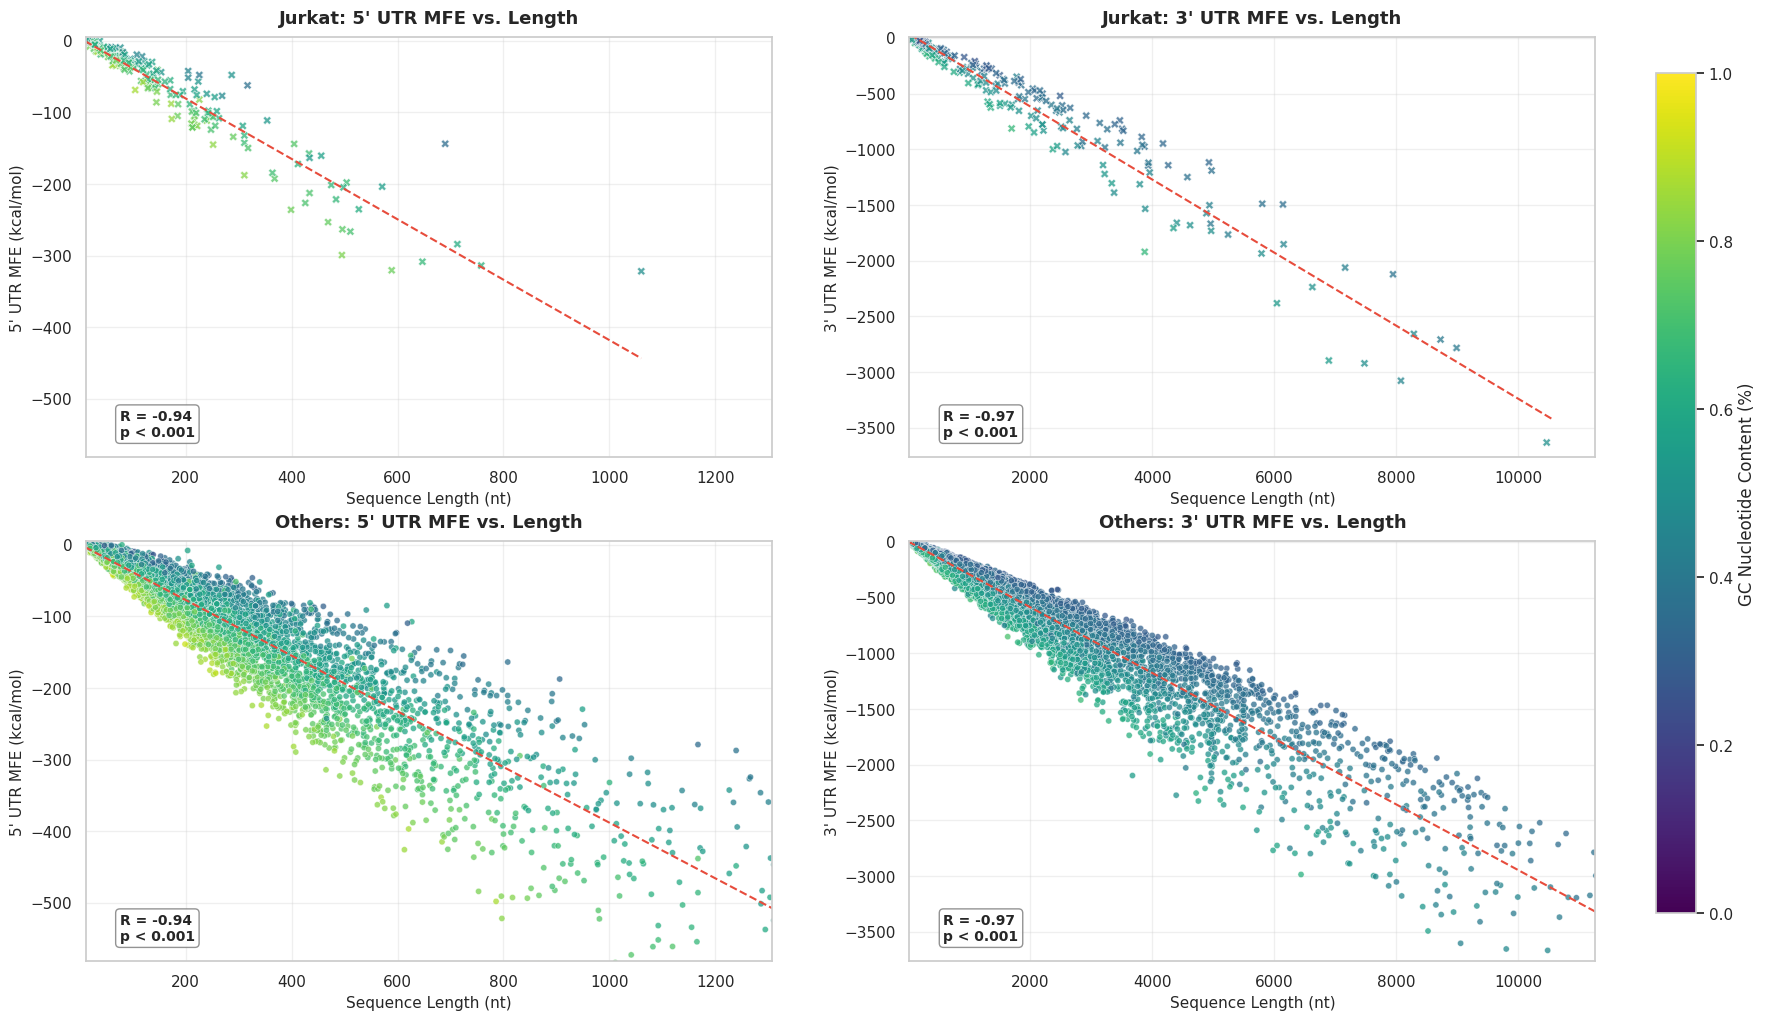

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr


# ==============================================================================
# 1. OPTIMIZED DATA PREPARATION (Unchanged)
# ==============================================================================
def prepare_scatter_data(df, dataset_name):
    processed = pd.DataFrame()

    processed["5_len"] = df["5_UTR"].dropna().astype(str).str.len()
    processed["3_len"] = df["3_UTR"].dropna().astype(str).str.len()

    processed["5_MFE"] = pd.to_numeric(df["5_UTR_MFE"], errors="coerce")
    processed["3_MFE"] = pd.to_numeric(df["3_UTR_MFE"], errors="coerce")
    processed["5_GC"] = pd.to_numeric(df["5_UTR_GC"], errors="coerce")
    processed["3_GC"] = pd.to_numeric(df["3_UTR_GC"], errors="coerce")

    processed["Dataset"] = dataset_name
    return processed.dropna()


df_jurkat = prepare_scatter_data(jurkat, "Jurkat")
df_others = prepare_scatter_data(rest, "Others")
combined = pd.concat([df_jurkat, df_others], ignore_index=True)


def annotate_regression(df, x_col, y_col, ax):
    x = df[x_col].values
    y = df[y_col].values
    if len(x) > 1:
        r, p = pearsonr(x, y)
        p_text = f"p < 0.001" if p < 0.001 else f"p = {p:.3f}"
        ax.text(
            0.05,
            0.05,
            f"R = {r:.2f}\n{p_text}",
            transform=ax.transAxes,
            fontsize=10,
            weight="bold",
            bbox=dict(
                facecolor="white", edgecolor="gray", alpha=0.85, boxstyle="round"
            ),
        )


# ==============================================================================
# 2. COMPUTE COLUMN-SPECIFIC SCALES (Locks comparison limits by region)
# ==============================================================================
# We use quantiles (0.5% to 99.5%) to automatically drop extreme sequencing artifacts
# or outlier noise that would otherwise mess up the axis framing.

# --- 5' UTR Shared Scaling ---
xlim_5_min, xlim_5_max = combined["5_len"].quantile(0.005), combined[
    "5_len"
].quantile(0.995)
ylim_5_min, ylim_5_max = (
    combined["5_MFE"].quantile(0.005) * 1.05,
    combined["5_MFE"].max() + 5,
)

# --- 3' UTR Shared Scaling ---
xlim_3_min, xlim_3_max = combined["3_len"].quantile(0.005), combined[
    "3_len"
].quantile(0.995)
ylim_3_min, ylim_3_max = (
    combined["3_MFE"].quantile(0.005) * 1.05,
    combined["3_MFE"].max() + 5,
)


# ==============================================================================
# 3. RUN 2x2 ANALYSIS MATRIX RENDERING
# ==============================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

matrix_config = [
    {
        "row": 0,
        "col": 0,
        "df": df_jurkat,
        "marker": "X",
        "size": 35,
        "x": "5_len",
        "y": "5_MFE",
        "gc": "5_GC",
        "xlim": (xlim_5_min, xlim_5_max),
        "ylim": (ylim_5_min, ylim_5_max),
        "title": "Jurkat: 5' UTR MFE vs. Length",
        "xl": "Sequence Length (nt)",
        "yl": "5' UTR MFE (kcal/mol)",
    },
    {
        "row": 0,
        "col": 1,
        "df": df_jurkat,
        "marker": "X",
        "size": 35,
        "x": "3_len",
        "y": "3_MFE",
        "gc": "3_GC",
        "xlim": (xlim_3_min, xlim_3_max),
        "ylim": (ylim_3_min, ylim_3_max),
        "title": "Jurkat: 3' UTR MFE vs. Length",
        "xl": "Sequence Length (nt)",
        "yl": "3' UTR MFE (kcal/mol)",
    },
    {
        "row": 1,
        "col": 0,
        "df": df_others,
        "marker": "o",
        "size": 20,
        "x": "5_len",
        "y": "5_MFE",
        "gc": "5_GC",
        "xlim": (xlim_5_min, xlim_5_max),
        "ylim": (ylim_5_min, ylim_5_max),
        "title": "Others: 5' UTR MFE vs. Length",
        "xl": "Sequence Length (nt)",
        "yl": "5' UTR MFE (kcal/mol)",
    },
    {
        "row": 1,
        "col": 1,
        "df": df_others,
        "marker": "o",
        "size": 20,
        "x": "3_len",
        "y": "3_MFE",
        "gc": "3_GC",
        "xlim": (xlim_3_min, xlim_3_max),
        "ylim": (ylim_3_min, ylim_3_max),
        "title": "Others: 3' UTR MFE vs. Length",
        "xl": "Sequence Length (nt)",
        "yl": "3' UTR MFE (kcal/mol)",
    },
]

# Shared Global Color Scale
gc_min = combined[["5_GC", "3_GC"]].min().min()
gc_max = combined[["5_GC", "3_GC"]].max().max()

for cfg in matrix_config:
    ax = axes[cfg["row"], cfg["col"]]
    sub_df = cfg["df"]

    if sub_df.empty:
        continue

    # Plot
    sns.scatterplot(
        data=sub_df,
        x=cfg["x"],
        y=cfg["y"],
        hue=cfg["gc"],
        palette="viridis",
        hue_norm=(gc_min, gc_max),
        marker=cfg["marker"],
        s=cfg["size"],
        alpha=0.75,
        legend=False,
        ax=ax,
    )

    # Trendline
    sns.regplot(
        data=sub_df,
        x=cfg["x"],
        y=cfg["y"],
        scatter=False,
        color="#e74c3c",
        line_kws={"linestyle": "--", "linewidth": 1.5},
        ci=None,
        ax=ax,
    )

    annotate_regression(sub_df, cfg["x"], cfg["y"], ax)

    ax.set_title(cfg["title"], fontsize=13, weight="bold", pad=10)
    ax.set_xlabel(cfg["xl"], fontsize=11)
    ax.set_ylabel(cfg["yl"], fontsize=11)

    # --- SET COHESIVE SCALE LIMITS PER COLUMN ---
    ax.set_xlim(cfg["xlim"])
    ax.set_ylim(cfg["ylim"])

# --- Universal Side-Car Colorbar Integration ---
norm = plt.Normalize(gc_min, gc_max)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(sm, cax=cbar_ax, label="GC Nucleotide Content (%)")

plt.show()